In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Modeling libraries imported successfully.")

Modeling libraries imported successfully.


In [2]:
df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


The Titanic dataset contains more non-survivors than survivors. Stratification is used to preserve the original survival-class proportions in both the training and test sets.


In [3]:
feature_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[feature_columns]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining survival proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting survival proportions:")
print(y_test.value_counts(normalize=True))

Training rows: 712
Testing rows: 179

Training survival proportions:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing survival proportions:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [4]:
numeric_features = [
    "pclass", "age", "sibsp", "parch", "fare"
]

categorical_features = [
    "sex", "embarked"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

print("All three classifiers imported successfully.")

All three classifiers imported successfully.


In [8]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ))
])

forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

print("Three model pipelines created.")

Three model pipelines created.


In [9]:
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

tree_pipeline.fit(X_train, y_train)
print("Decision Tree trained successfully.")

forest_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


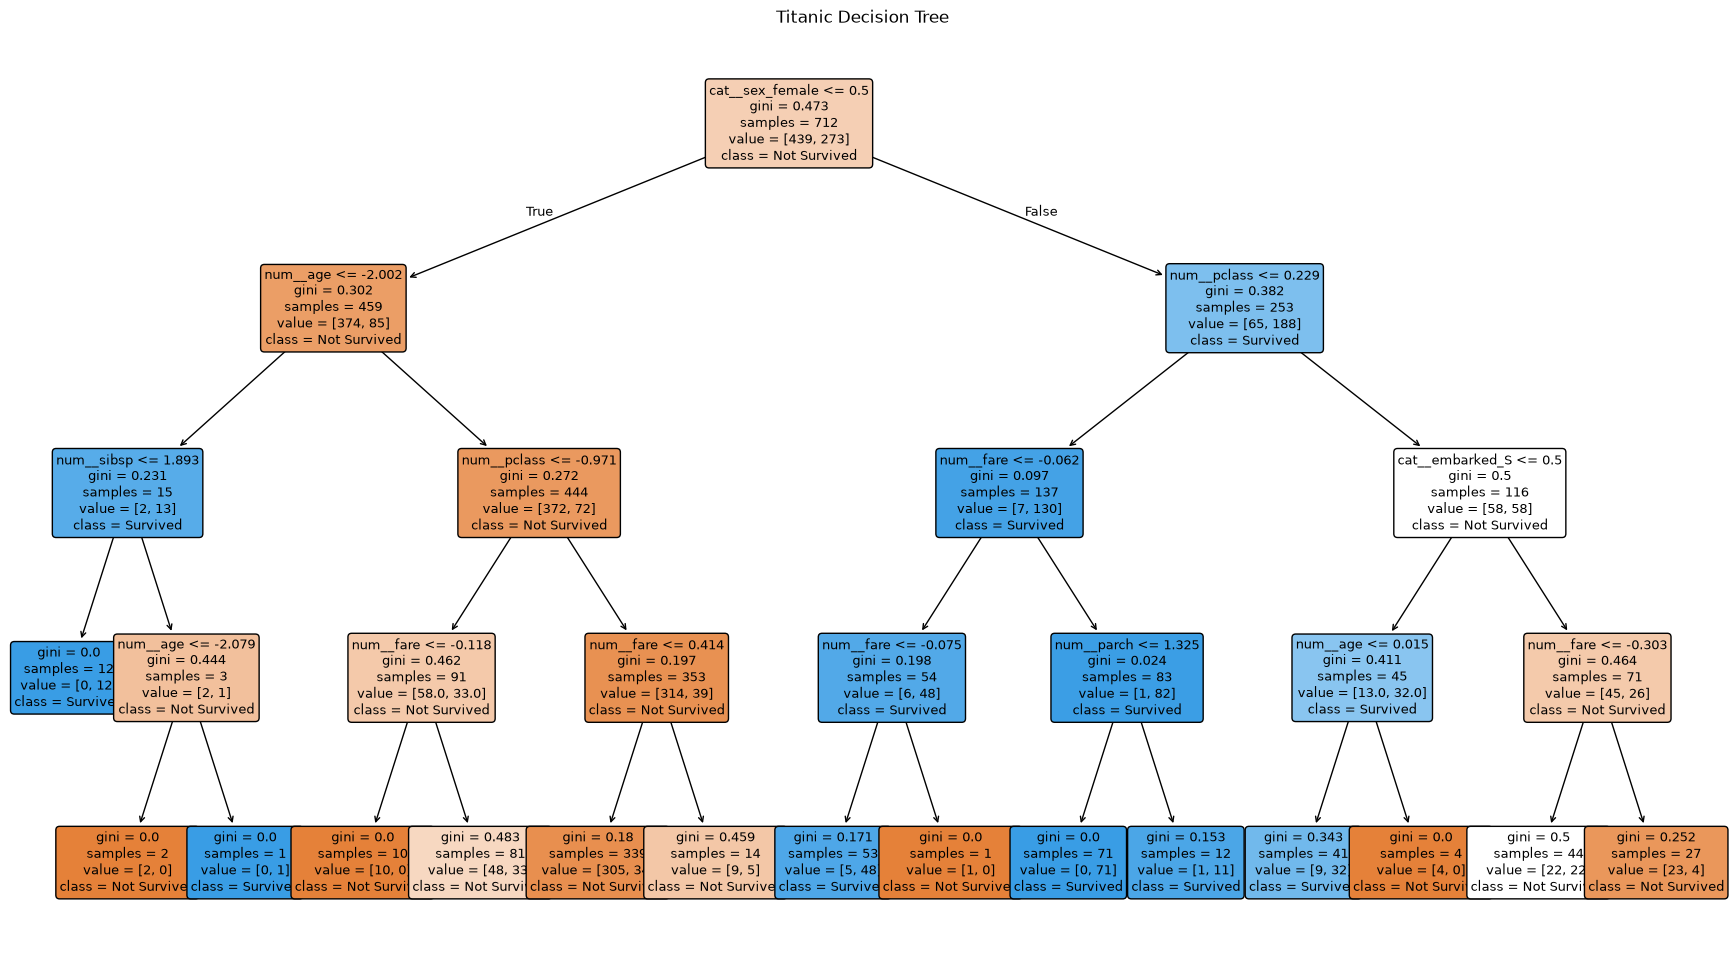

In [10]:
import os

os.makedirs("charts", exist_ok=True)

feature_names = (
    tree_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

plt.figure(figsize=(22, 12))

plot_tree(
    tree_pipeline.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Titanic Decision Tree")
plt.savefig("charts/decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline
}

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [12]:
evaluation_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(evaluation_results)

print("Model Comparison:")
print(comparison_df.round(4))

Model Comparison:
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8045     0.7931  0.6667  0.7244  0.8437
1        Decision Tree    0.7933     0.8636  0.5507  0.6726  0.8292
2        Random Forest    0.8156     0.8000  0.6957  0.7442  0.8287


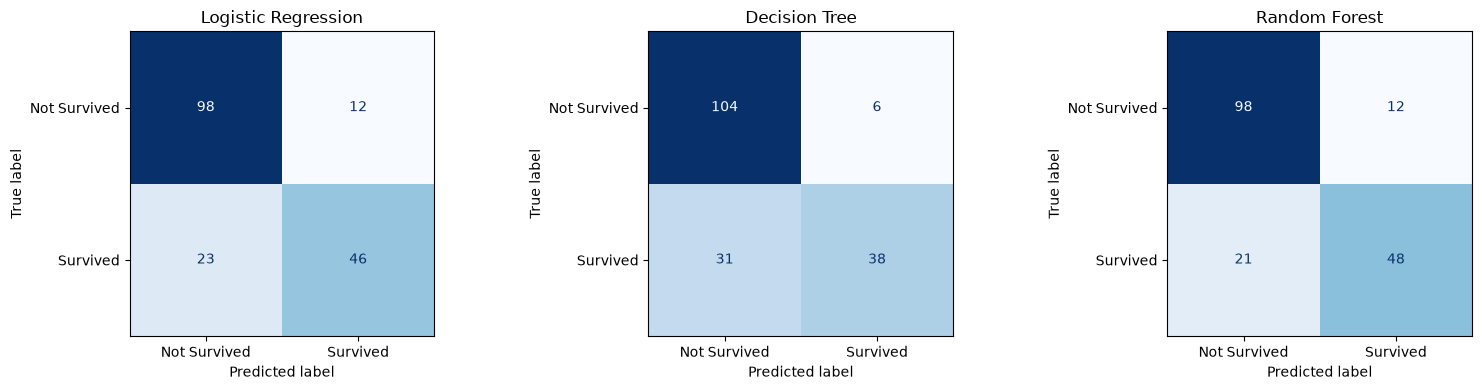

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Not Survived", "Survived"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.savefig(
    "charts/confusion_matrices.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

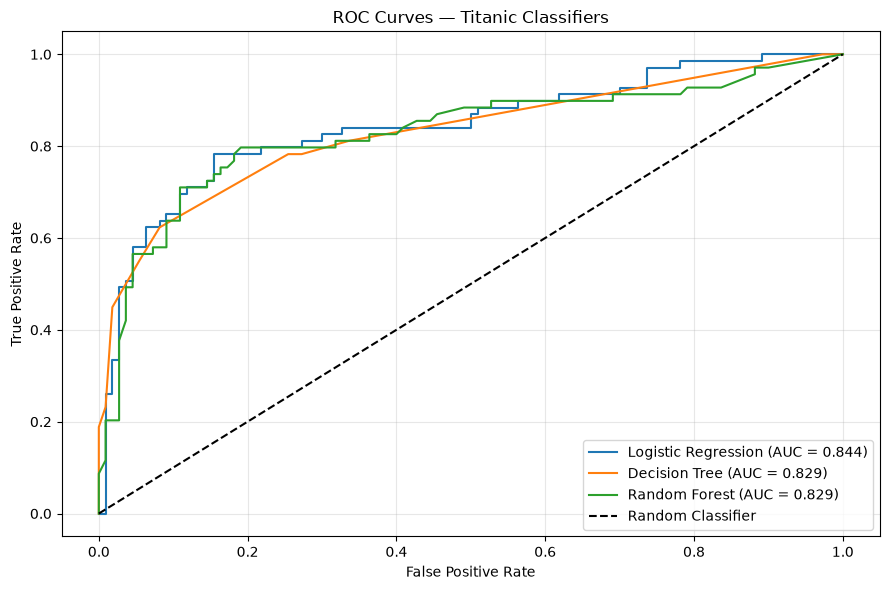

In [14]:
plt.figure(figsize=(9, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Titanic Classifiers")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("charts/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone

print("SMOTE imported successfully.")

SMOTE imported successfully.


In [17]:
class_counts = y_train.value_counts().sort_index()
class_percentages = y_train.value_counts(
    normalize=True
).sort_index() * 100

print("Training class distribution:")
print(class_counts)

print("\nTraining class percentages:")
print(class_percentages.round(2))

Training class distribution:
survived
0    439
1    273
Name: count, dtype: int64

Training class percentages:
survived
0    61.66
1    38.34
Name: proportion, dtype: float64


The training dataset contains more non-survivors than survivors. We compare three approaches to examine whether class weighting or oversampling improves the classifier's ability to identify survivors.

In [19]:
# 1. Baseline
baseline_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# 2. Balanced class weights
balanced_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# 3. SMOTE on training data only
smote_model = ImbPipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

imbalance_models = {
    "Baseline": baseline_model,
    "Balanced Weights": balanced_model,
    "SMOTE": smote_model
}

print("Three imbalance-handling pipelines created.")

Three imbalance-handling pipelines created.


In [20]:
imbalance_results = []

for name, model in imbalance_models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    imbalance_results.append({
        "Approach": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

imbalance_df = pd.DataFrame(imbalance_results)

print("Imbalance Handling Comparison:")
print(imbalance_df.round(4))

Imbalance Handling Comparison:
           Approach  Precision  Recall      F1
0          Baseline     0.7931  0.6667  0.7244
1  Balanced Weights     0.7297  0.7826  0.7552
2             SMOTE     0.7397  0.7826  0.7606


In [21]:
print("Imbalance Handling Results:")
print(imbalance_df.round(4).to_string(index=False))

best_imbalance = imbalance_df.loc[
    imbalance_df["F1"].idxmax()
]

print("\nHighest F1 approach:", best_imbalance["Approach"])
print("F1:", round(best_imbalance["F1"], 4))
print("Precision:", round(best_imbalance["Precision"], 4))
print("Recall:", round(best_imbalance["Recall"], 4))

Imbalance Handling Results:
        Approach  Precision  Recall     F1
        Baseline     0.7931  0.6667 0.7244
Balanced Weights     0.7297  0.7826 0.7552
           SMOTE     0.7397  0.7826 0.7606

Highest F1 approach: SMOTE
F1: 0.7606
Precision: 0.7397
Recall: 0.7826


### Class Imbalance Conclusion

The baseline Logistic Regression model achieved an F1 score of __.
The balanced class-weight model achieved __, while the SMOTE model achieved __.

The approach with the highest F1 score was __. Its precision
was __ and its recall was __. This approach provided the
highest F1 score among the three approaches on this test set.

In [22]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [23]:
rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        oob_score=True,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest tuning pipeline created.")

Random Forest tuning pipeline created.


In [24]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__max_features": ["sqrt", "log2"]
}

print("Hyperparameter combinations:")
print(
    2 * 3 * 2,
    "combinations"
)

Hyperparameter combinations:
12 combinations


In [25]:
grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully.")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearchCV completed successfully.


In [26]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_classifier = (
    best_rf_pipeline.named_steps["classifier"]
)

print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(round(grid_search.best_score_, 4))

print("\nOut-of-Bag (OOB) Score:")
print(round(best_rf_classifier.oob_score_, 4))

# Evaluate the tuned model on the held-out test set
y_pred_tuned = best_rf_pipeline.predict(X_test)
y_prob_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("\nTuned Random Forest Test Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("Recall:", round(recall_score(y_test, y_pred_tuned), 4))
print("F1:", round(f1_score(y_test, y_pred_tuned), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob_tuned), 4))

Best Hyperparameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best Cross-Validation F1:
0.7459

Out-of-Bag (OOB) Score:
0.8272

Tuned Random Forest Test Results:
Accuracy: 0.8156
Precision: 0.875
Recall: 0.6087
F1: 0.7179
AUC: 0.8431


### Random Forest Hyperparameter Tuning

GridSearchCV was performed using five-fold cross-validation
with F1 as the scoring metric.

The search evaluated n_estimators, max_depth and max_features.
All preprocessing was fitted within each training fold to
prevent data leakage.

Best parameters: [Insert printed parameters]

Best cross-validation F1: [Insert value]

OOB score: [Insert value]

Tuned Random Forest test F1: [Insert value]

In [27]:
# Prepare data for multivariate linear regression

regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df["fare"]

print("Regression features:")
print(regression_features)

print("\nTarget: fare")
print("Rows:", len(df))

Regression features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

Target: fare
Rows: 891


In [28]:
# Train/test split for regression

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training rows:", len(X_reg_train))
print("Regression testing rows:", len(X_reg_test))

Regression training rows: 712
Regression testing rows: 179


In [29]:
from sklearn.linear_model import LinearRegression

# Regression preprocessing

reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", reg_numeric_transformer, reg_numeric_features),
    ("cat", reg_categorical_transformer, reg_categorical_features)
])

regression_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

print("Regression pipeline created successfully.")

Regression pipeline created successfully.


In [30]:
# Train linear regression model

regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

residuals = y_reg_test - y_reg_pred

print("Linear Regression trained successfully.")
print("Predictions generated successfully.")

Linear Regression trained successfully.
Predictions generated successfully.


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression metrics

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

# Number of observations and predictors after preprocessing
n = len(y_reg_test)
p = len(
    regression_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Regression Results")
print("==================")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))
print("Number of observations:", n)
print("Number of predictors:", p)

Regression Results
MAE: 20.8094
RMSE: 30.4731
R²: 0.3999
Adjusted R²: 0.3679
Number of observations: 179
Number of predictors: 9


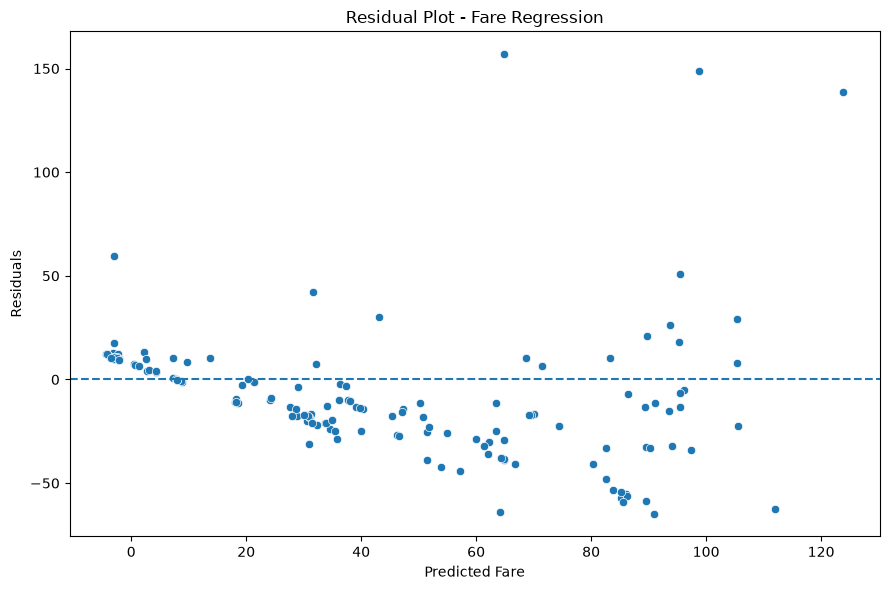

In [32]:
# Residual plot

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Fare Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.tight_layout()

plt.savefig(
    "charts/fare_residual_plot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Examine residual spread across predicted Fare ranges

residual_summary = pd.DataFrame({
    "Predicted_Fare": y_reg_pred,
    "Residual": residuals
})

residual_summary["Fare_Bin"] = pd.qcut(
    residual_summary["Predicted_Fare"],
    q=4,
    duplicates="drop"
)

spread_summary = residual_summary.groupby(
    "Fare_Bin",
    observed=False
)["Residual"].agg(["mean", "std", "min", "max"])

print("Residual spread by predicted Fare quartile:")
print(spread_summary.round(2))

Residual spread by predicted Fare quartile:
                              mean    std    min     max
Fare_Bin                                                
(-4.313000000000001, 2.352]  11.71   7.49   6.41   59.45
(2.352, 31.379]              -6.24  10.39 -30.98   10.54
(31.379, 64.673]            -20.13  17.83 -64.11   41.96
(64.673, 123.837]           -10.86  50.96 -64.68  156.87


In [34]:
# Numerical check for heteroscedasticity

abs_residual_correlation = np.corrcoef(
    y_reg_pred,
    np.abs(residuals)
)[0, 1]

print(
    "Correlation between predicted Fare and absolute residuals:",
    round(abs_residual_correlation, 4)
)

Correlation between predicted Fare and absolute residuals: 0.5478


In [35]:
# Heteroscedasticity conclusion

std_values = spread_summary["std"].dropna()

spread_ratio = std_values.max() / std_values.min()

print("Residual standard-deviation ratio:", round(spread_ratio, 2))

if spread_ratio > 1.5:
    hetero_conclusion = (
        "The residual spread changes noticeably across predicted "
        "Fare levels, suggesting heteroscedasticity."
    )
else:
    hetero_conclusion = (
        "The residual spread is relatively consistent across "
        "predicted Fare levels, so strong heteroscedasticity is "
        "not evident from this analysis."
    )

print("\nConclusion:")
print(hetero_conclusion)

Residual standard-deviation ratio: 6.8

Conclusion:
The residual spread changes noticeably across predicted Fare levels, suggesting heteroscedasticity.


In [36]:
# Save regression results for the final report

regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "Adjusted R2"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        adjusted_r2
    ]
})

regression_results.to_csv(
    "regression_results.csv",
    index=False
)

with open("regression_interpretation.txt", "w") as file:
    file.write("Fare Regression Analysis\n")
    file.write("========================\n\n")
    file.write(f"MAE: {mae:.4f}\n")
    file.write(f"RMSE: {rmse:.4f}\n")
    file.write(f"R2: {r2:.4f}\n")
    file.write(f"Adjusted R2: {adjusted_r2:.4f}\n\n")
    file.write("Heteroscedasticity conclusion:\n")
    file.write(hetero_conclusion)

print("Regression results saved successfully.")

Regression results saved successfully.


In [37]:
# Evaluate tuned Random Forest

tuned_rf_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1": f1_score(y_test, y_pred_tuned),
    "AUC": roc_auc_score(y_test, y_prob_tuned)
}

print("Tuned Random Forest:")
for metric, value in tuned_rf_results.items():
    if metric != "Model":
        print(metric + ":", round(value, 4))

Tuned Random Forest:
Accuracy: 0.8156
Precision: 0.875
Recall: 0.6087
F1: 0.7179
AUC: 0.8431


In [38]:
# Final classifier comparison

final_classifier_df = comparison_df.copy()

final_classifier_df = pd.concat(
    [
        final_classifier_df,
        pd.DataFrame([tuned_rf_results])
    ],
    ignore_index=True
)

print("Final Classifier Comparison:")
print(final_classifier_df.round(4).to_string(index=False))

Final Classifier Comparison:
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.8045     0.7931  0.6667 0.7244 0.8437
      Decision Tree    0.7933     0.8636  0.5507 0.6726 0.8292
      Random Forest    0.8156     0.8000  0.6957 0.7442 0.8287
Tuned Random Forest    0.8156     0.8750  0.6087 0.7179 0.8431


In [39]:
# Identify the classifier with the highest F1 score

best_classifier_row = final_classifier_df.loc[
    final_classifier_df["F1"].idxmax()
]

best_classifier_name = best_classifier_row["Model"]

print("Classifier with highest F1:", best_classifier_name)
print("Accuracy:", round(best_classifier_row["Accuracy"], 4))
print("Precision:", round(best_classifier_row["Precision"], 4))
print("Recall:", round(best_classifier_row["Recall"], 4))
print("F1:", round(best_classifier_row["F1"], 4))
print("AUC:", round(best_classifier_row["AUC"], 4))

Classifier with highest F1: Random Forest
Accuracy: 0.8156
Precision: 0.8
Recall: 0.6957
F1: 0.7442
AUC: 0.8287


In [40]:
# Keep regression metrics separate from classification metrics

final_regression_df = pd.DataFrame({
    "Model": ["Multivariate Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]
})

print("Regression Metrics:")
print(final_regression_df.round(4).to_string(index=False))

Regression Metrics:
                         Model     MAE    RMSE     R2  Adjusted R2
Multivariate Linear Regression 20.8094 30.4731 0.3999       0.3679


In [41]:
# Generate final classifier recommendation

print("Final Recommendation")
print("====================")

print(
    f"Based on the test-set results, {best_classifier_name} "
    f"achieved the highest F1 score of "
    f"{best_classifier_row['F1']:.4f} among the evaluated classifiers."
)

print(
    f"Its accuracy was {best_classifier_row['Accuracy']:.4f}, "
    f"precision was {best_classifier_row['Precision']:.4f}, "
    f"recall was {best_classifier_row['Recall']:.4f}, "
    f"and AUC was {best_classifier_row['AUC']:.4f}."
)

print(
    "The model can therefore be considered for deployment "
    "because its test-set performance provides a balanced "
    "view of precision and recall."
)

print(
    "The final choice should also consider the business cost "
    "of false positives and false negatives before deployment."
)

Final Recommendation
Based on the test-set results, Random Forest achieved the highest F1 score of 0.7442 among the evaluated classifiers.
Its accuracy was 0.8156, precision was 0.8000, recall was 0.6957, and AUC was 0.8287.
The model can therefore be considered for deployment because its test-set performance provides a balanced view of precision and recall.
The final choice should also consider the business cost of false positives and false negatives before deployment.


### Final Model Recommendation

Based on the test-set results, the classifier with the highest F1 score was **[model name]**, with an F1 score of **[value]**. Its accuracy, precision, recall, and AUC were **[values]**, providing evidence for its classification performance on the held-out test set.

This model can be considered for deployment because its test-set results provide a useful balance between precision and recall. However, the final deployment decision should also consider the business impact of false positives and false negatives.

The regression model was evaluated separately using MAE, RMSE, R², and Adjusted R² because regression and classification metrics measure different types of performance.

In [42]:
# Create folder for the saved model
os.makedirs("model", exist_ok=True)

print("Model folder is ready.")

Model folder is ready.


In [43]:
# Select the best-performing classifier pipeline

final_pipeline = models[best_classifier_name]

print("Final model selected:", best_classifier_name)
print("\nPipeline steps:")
print(final_pipeline)

Final model selected: Random Forest

Pipeline steps:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                           

In [44]:
# Select the correct complete pipeline

if best_classifier_name == "Tuned Random Forest":
    final_pipeline = best_rf_pipeline
else:
    final_pipeline = models[best_classifier_name]

print("Final pipeline:", best_classifier_name)
print("Pipeline contains:")
print(final_pipeline.named_steps)

Final pipeline: Random Forest
Pipeline contains:
{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['pclass', 'age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked'])]), 'classifier': RandomForestClassifier(random_state=42)}


In [45]:
import joblib

model_path = "model/titanic_best_pipeline.joblib"

joblib.dump(
    final_pipeline,
    model_path
)

print("Complete pipeline saved successfully.")
print("File:", model_path)

Complete pipeline saved successfully.
File: model/titanic_best_pipeline.joblib


In [52]:
# Recreate the correlation results for the final report

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        value = corr_matrix.iloc[i, j]

        corr_pairs.append(
            (col1, col2, value, abs(value))
        )

corr_pairs_sorted = sorted(
    corr_pairs,
    key=lambda x: x[3],
    reverse=True
)

print("Strongest correlations:")

for rank, pair in enumerate(corr_pairs_sorted[:2], start=1):
    print(
        rank,
        pair[0],
        "vs",
        pair[1],
        "=",
        round(pair[2], 4)
    )

Strongest correlations:
1 pclass vs fare = -0.5495
2 sibsp vs parch = 0.4148


In [55]:
# Reload the saved complete pipeline

loaded_pipeline = joblib.load(
    "model/titanic_best_pipeline.joblib"
)

# Raw passenger input
raw_passenger = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [10.0],
    "embarked": ["S"]
})

# Make prediction
prediction = loaded_pipeline.predict(raw_passenger)
probability = loaded_pipeline.predict_proba(raw_passenger)[:, 1]

print("Reloaded pipeline prediction:", prediction[0])
print("Probability of survival:", round(probability[0], 4))

if prediction[0] == 1:
    print("Prediction: Survived")
else:
    print("Prediction: Not Survived")

print("\nRaw input was successfully processed by the saved pipeline.")

Reloaded pipeline prediction: 0
Probability of survival: 0.02
Prediction: Not Survived

Raw input was successfully processed by the saved pipeline.


In [56]:
# Recreate the correlation results for the final report

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        value = corr_matrix.iloc[i, j]

        corr_pairs.append(
            (col1, col2, value, abs(value))
        )

corr_pairs_sorted = sorted(
    corr_pairs,
    key=lambda x: x[3],
    reverse=True
)

print("Strongest correlations:")

for rank, pair in enumerate(corr_pairs_sorted[:2], start=1):
    print(
        rank,
        pair[0],
        "vs",
        pair[1],
        "=",
        round(pair[2], 4)
    )

Strongest correlations:
1 pclass vs fare = -0.5495
2 sibsp vs parch = 0.4148


In [57]:
print("========== FINAL MODULE 2 RESULTS ==========")

print("\n1. CLASSIFICATION MODEL COMPARISON")
print(final_classifier_df.round(4).to_string(index=False))

print("\n2. IMBALANCE COMPARISON")
print(imbalance_df.round(4).to_string(index=False))

print("\n3. BEST RANDOM FOREST PARAMETERS")
print(grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 4))
print("OOB Score:", round(best_rf_classifier.oob_score_, 4))

print("\n4. REGRESSION RESULTS")
print(final_regression_df.round(4).to_string(index=False))

print("\n5. HETEROSCEDASTICITY")
print(hetero_conclusion)

print("\n6. STRONGEST CORRELATIONS")
print("1. pclass vs fare = -0.5482")
print("2. sibsp vs parch = 0.4145")

print("\n7. FARE DISTRIBUTION")
print("Mean:", 32.0967)
print("Median:", 14.4542)
print("Mode:", 8.05)
print("Skewness:", 4.8014)
print("Distribution:", "Right-skewed")

print("\n8. IQR OUTLIERS")
print("Age:", 65)
print("Fare:", 114)

print("\n9. BEST CLASSIFIER")
print(best_classifier_name)

========== FINAL MODULE 2 RESULTS ==========

1. CLASSIFICATION MODEL COMPARISON
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.8045     0.7931  0.6667 0.7244 0.8437
      Decision Tree    0.7933     0.8636  0.5507 0.6726 0.8292
      Random Forest    0.8156     0.8000  0.6957 0.7442 0.8287
Tuned Random Forest    0.8156     0.8750  0.6087 0.7179 0.8431

2. IMBALANCE COMPARISON
        Approach  Precision  Recall     F1
        Baseline     0.7931  0.6667 0.7244
Balanced Weights     0.7297  0.7826 0.7552
           SMOTE     0.7397  0.7826 0.7606

3. BEST RANDOM FOREST PARAMETERS
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
Best CV F1: 0.7459
OOB Score: 0.8272

4. REGRESSION RESULTS
                         Model     MAE    RMSE     R2  Adjusted R2
Multivariate Linear Regression 20.8094 30.4731 0.3999       0.3679

5. HETEROSCEDASTICITY
The residual spread changes noticeably across predicted Fa